# Micrograd
Micrograd is about tracing a multi-step calculation and measuring how each starting value influences the final result, so we can change those starting values to improve the outcome.

### What gradient means here

If:
```text
d = a*b + 4
```

Then:

```text
dd/da = b
dd/db = a
```

So if:
```text
a = 2
b = 3
```
Then:
```text
dd/da = 3
dd/db = 2
```
Meaning:

- increase ```a``` a little → final output ```d``` increases about 3x that amount </br>
- increase ```b``` a little → final output ```d``` increases about 2x that amount </br>

In [98]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [99]:
def f(x):
    return 3*x**2 - 4*x + 5

In [100]:
f(3.0)

20.0

In [101]:
xs = np.arange(-5, 5, 0.25) # NumPy array of numbers from -5 to just before 5, with step size 0.25
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

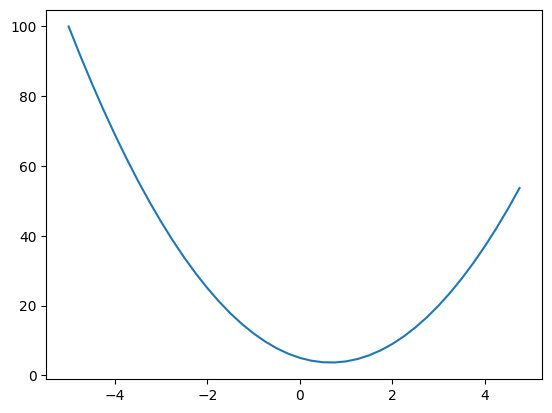

In [102]:
plt.plot(xs, ys)

In [103]:
class Value:
    # children will store the child elements which created self
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0 # it represents the derivative of the output w.r.t current object's value
        self._backward = lambda: None
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self, other):
        # add takes self and other then returns a new Value
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        # so we need to assign _backward function to self and other
        # If A + B = C
        # and if we need dL/dB = dL/dC * dC/dB
        # Since, dC/dB = 1
        # therefore, dL/dB = dL/dC (we won't have the case for coefficient since Value itself has the complete value in it)
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
        # If A * B = C
        # and if we need dL/dB = dL/dC * dC/dB = dL/dC * A
            self.grad += other.data * out.grad
            # we are accumulating because if a + b = c and a + b = d and c + d = L then a is contributing twice
            # so if we overwrite it using = then we will lost its contribution for c
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other): # fallback for situation like 2 * Value(a)
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only int/float powers supported"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = backward
        return out

    # whenever we do division, it gets converted into multiplication and power. power part is handled by __pow__ function
    def __truediv__(self, other):
        return self * other ** -1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        # out = Value(self.data - other.data, (self, other), '-')

        # def backward():
        #     self.grad += out.grad
        #     other.grad += -1 * out.grad

        # out._backward = backward
        # return out
        return self + (-other)
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        # C = e^B (since we do one operation at a time)
        # therefore, dL/dB = dL/dC (out.grad) * dC/dB (=out.data)
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out
        

    # def division(self, other):
    #     out = Value(self.data / other.data, (self, other), '/')
    #     def _backward():
    #         self.grad += self.grad 
    #     out._backward = _backward
    #     return out

    def backward(self):
        topo = []
        visited = set()
    
        def dfs(node):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    dfs(child)
                topo.append(node)
    
        dfs(self)
        self.grad = 1.0
        for n in reversed(topo):
            n._backward()
            
a = Value(5, label='a')
b = Value(-1, label='b')
c = Value(1, label='c')
d = a * b + c

In [104]:
d._prev

{Value(data=-5), Value(data=1)}

In [105]:
d._op

'+'

In [106]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad),
            shape='record'
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

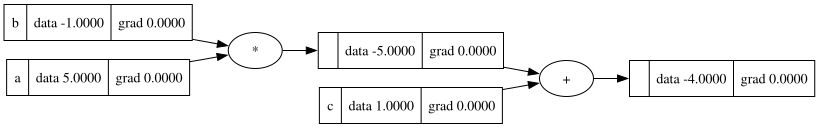

In [107]:
draw_dot(d)

**If a node A affects the final output L through a single next node B, then:**

$\frac{dL}{dA} = \frac{dL}{dB} \cdot \frac{dB}{dA}$

**This means:**

* take the gradient flowing from the output (`dL/dB`)
* multiply by the local derivative at the current step (`dB/dA`)

**If there are multiple paths from A to L, compute this for each path and add them.**

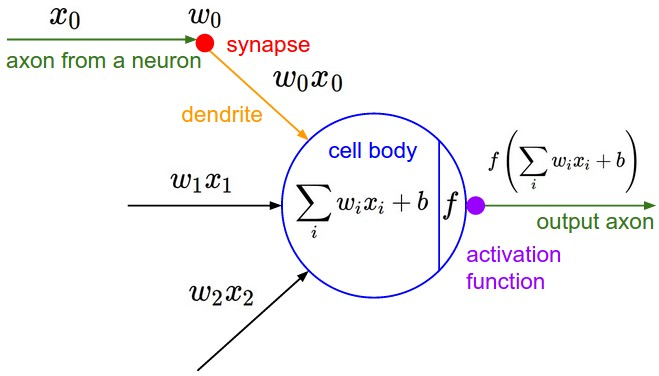

*Figure: Mathematical illustration of a neuron*

## Artificial Neuron

An artificial neuron is the basic building block of a neural network. It receives one or more input values, processes them using weights and a bias, and then produces an output. The purpose of the neuron is to learn how strongly each input should influence the output.

Each input has its own corresponding weight. These weights are learnable parameters, meaning they are adjusted during training so that the network can make better predictions. A large positive weight increases the influence of an input, a negative weight reduces or reverses its influence, and a weight close to zero means that the input has little effect on the neuron’s output.

The neuron first multiplies each input by its corresponding weight and then sums all of these weighted values. After this, a bias term is added. The bias is also a learnable parameter, and it allows the neuron to shift the output independently of the input values. This makes the neuron more flexible and helps it fit data better.

Mathematically, the raw output of the neuron is:

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

where:
- x₁, x₂, ..., xₙ are the input values
- w₁, w₂, ..., wₙ are the corresponding weights
- b is the bias
- z is the weighted sum before activation

The value `z` is then passed through an activation function:

out = f(z)

where:
- f is the activation function
- out is the final output of the neuron

## Role of Weights

Weights determine the importance of each input feature.

Examples:
- If a weight is large and positive, that input strongly increases the neuron’s output.
- If a weight is large and negative, that input strongly decreases the neuron’s output.
- If a weight is near zero, that input contributes very little.

Because each input has its own connection to the neuron, each input also has its own weight. This is why a single neuron can have multiple different weights.

For example, if a neuron has three inputs:

x₁, x₂, x₃

then it will usually have three weights:

w₁, w₂, w₃

So the neuron computes:

z = w₁x₁ + w₂x₂ + w₃x₃ + b

## Role of Bias

The bias is a constant term added after the weighted sum. It helps shift the activation value left or right and allows the neuron to produce a non-zero output even when all inputs are zero.

Without a bias term, the neuron would be more limited in the kinds of functions it could represent.

## Role of the Activation Function

The activation function is applied after computing the weighted sum. Its main purpose is to introduce **non-linearity** into the network.

Why this matters:
- Without an activation function, the neuron only performs a linear transformation.
- If we stack many neurons without activation functions, the entire network still behaves like a single linear transformation.
- This would make the network too limited to learn complex patterns such as curves, decision boundaries, or complicated relationships in data.

The activation function changes the raw value `z` into the final output `out`, which is then passed to the next layer.

### Common activation functions

1. **ReLU (Rectified Linear Unit)**  
   f(x) = max(0, x)  
   - Negative values become 0  
   - Positive values stay unchanged  
   - Very common in hidden layers

2. **Sigmoid**  
   f(x) = 1 / (1 + e^(-x))  
   - Squashes values between 0 and 1  
   - Often used when the output represents a probability in binary classification

3. **Tanh**  
   f(x) = tanh(x)  
   - Squashes values between -1 and 1  
   - Often used in educational examples like micrograd because it is smooth and easy to visualize

## Intuition

You can think of a neuron in three stages:

1. **Collect information** from the inputs  
2. **Decide importance** using weights and bias  
3. **Transform the result** using an activation function

So in simple terms:
- Inputs provide information
- Weights decide how important each input is
- Bias shifts the result
- Activation function decides the final signal sent forward

## Final Summary

A neuron takes multiple inputs, multiplies each by its own weight, adds all the weighted inputs together, and then adds a bias term. This produces a raw value `z`. The raw value is passed through an activation function, which introduces non-linearity and produces the final output. During training, the weights and bias are adjusted so that the neuron learns useful patterns from data.

In [108]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x1*w1"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n.label = "n"
o = n.tanh(); o.label = "o"


In [109]:
o.backward()

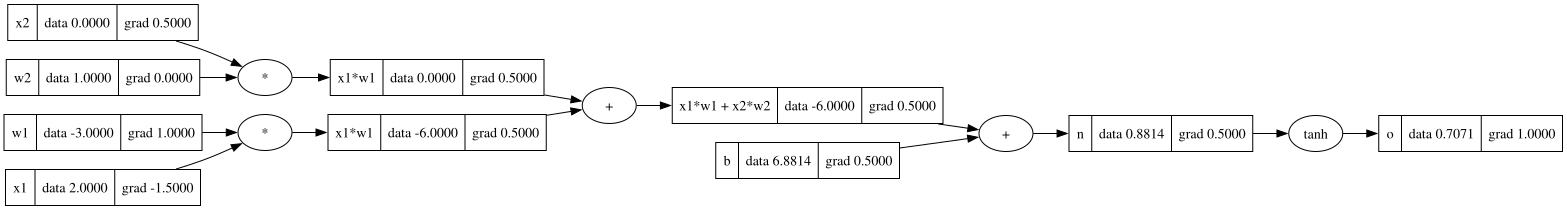

In [110]:
draw_dot(o)

In [111]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.8813735870195432, label="b")

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = "x1*w1"
x2w2 = x2*w2; x2w2.label = "x1*w1"

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = "x1*w1 + x2*w2"
n = x1w1x2w2 + b; n.label = "n"
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.label = "o"
o.backward()

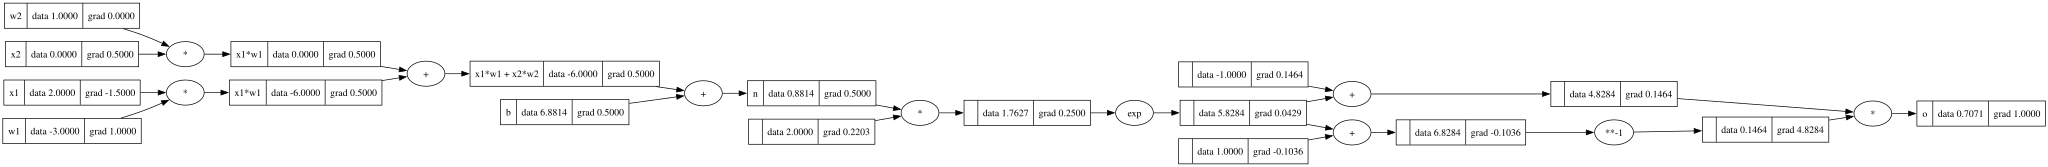

In [112]:
draw_dot(o)

# Using PyTorch


In PyTorch, we use tensors. The micrograd which we implemented is useful only for scaler values (i.e only 1 value) but tensors can hold multidimensional vectors like -

[[1, 2, 3],
[4, 5, 6]]


In [113]:
import torch

In [114]:
x1 = torch.Tensor([2.0]).double()

In [115]:
x1.shape

torch.Size([1])

In [116]:
x1.requires_grad

False

In [117]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()
print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [118]:
import random
class Neuron:
    # random.uniform(a, b) gives a random float between a and b
    # nin: number of inputs to the neuron
    # w: weight for each input
    # b: bias of the neuron

    def __init__(self, nin): 
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] 
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # computes w1*x1 + w2*x2 + w3*x3 + ... + b
        # forward pass of the neuron based on the input
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh() # activation function
        return out
        
    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    # nin: nin for each neuron and nout: total number of neurons to make
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    # pass the input and create the output for each of the neuron for the current layer
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
            if not isinstance(x, list):
                x = [x]
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

"""
2 inputs → 3 neurons → 1 output

Layer 1 - (2 inputs, 3 neurons)
Neuron1: (x1, x2)
Neuron2: (x1, x2)
Neuron3: (x1, x2)

Layer 2 - (3 inputs, 1 neuron)
Neuron1: (a, b, c)

Now, for MLP(2, [3, 1])

it'll first do [2] + [3, 1]
and loop for [2, 3] and [3, 1] and call Layer class for both
so it'll create 2 Layers -
* Layer1: 2 inputs and 3 neurons
* Layer2: 3 inputs and 1 neuron

and then it'll call output for each layer which will in turn give output for each neuron in that layer
so, finally we will get output for Layer2 with 1 neuron
but how're we giving the output of Layer1 to Layer2 neuron?
> This is happening when we are doing x = layer(x), x holds the output from Layer1 and gives it to Layer2


"""

n = MLP(3, [4, 4, 1])

x = [2.0, 3.0, -1]
n(x)

# print(n)          # output Value
# n.backward()      # compute gradients

# # print gradients
# for p in mlp.parameters():
#     print(p.grad)

Value(data=0.5114542029839708)

In [119]:
# draw_dot(n)

```python
mlp = MLP(3, [4, 4, 1])

x = [2.0, 3.0, -1]
y = mlp(x)
```
The above code creates -
Layer 1: 3 inputs, 4 neurons
Layer 2: 4 inputs, 4 neurons
Layer 3: 4 inputs, 1 neuron

and x is the input for the first neuron.

In the above image, tanh indicates the ending of each neuron. If we backtrack a neuron, we can se that in layer 1, there are 3 inputs given to each neuron and for one of the neuron a bias b is added.

In [120]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
] # inputs

ys = [1.0, -1.0, -1.0, 1.0] # desired outputs

In [127]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)** 2 for ygt, yout in zip(ys, ypred))
loss # first loss

Value(data=5.573519310969478)

In [126]:
len(n.parameters()) # total parameters of this neural net

41

In [137]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)** 2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.4749048253271071)

In [138]:
loss.backward()

In [142]:
for p in n.parameters():
    p.data += -0.01*p.grad

# reset the grad to zero so that it doesn't gets cumulated when we do .backward() (since its implementation accumulates the old values)
for p in n.parameters():
    p.grad = 0.0

In [139]:
ypred

[Value(data=0.9794866806433825),
 Value(data=-0.8855338549281434),
 Value(data=-0.32122207137207376),
 Value(data=0.9746612096569108)]

We tune the value of each neuron through the cell 136 in the opposite direction of grad because we want to minimize the loss. After that, we re-run the ypred and calculate the loss. As we can see, the loss decreases after few iterations and the value of ypred gets close to the desired outputs.

So the process is -
Tune params -> run forward pass to calculate the loss -> run backward pass to re-calculate the grad

For larger models, we don't do forward pass for the whole neural net. Instead, we pick a batch of neural net and perform forward pass on that batch.

In [140]:
n.parameters()

[Value(data=-0.18622715382309477),
 Value(data=0.6243981902343114),
 Value(data=-0.7945322651779494),
 Value(data=0.05732441608560132),
 Value(data=-0.6663787001371541),
 Value(data=-0.8171728223906098),
 Value(data=0.29096693090952236),
 Value(data=-1.0234751927069772),
 Value(data=0.2179091105469158),
 Value(data=0.6511501917989065),
 Value(data=-0.5714539368063115),
 Value(data=-0.25719679922681105),
 Value(data=0.8829088517650282),
 Value(data=0.9138495060264357),
 Value(data=-0.37386991202732045),
 Value(data=0.6137783327293878),
 Value(data=-1.3570488567172538),
 Value(data=-0.07595035034224235),
 Value(data=-0.6202027494837403),
 Value(data=0.4497955519555656),
 Value(data=-0.1423978570826968),
 Value(data=-0.7868917239659193),
 Value(data=-0.4185409718904217),
 Value(data=-0.029552223876862502),
 Value(data=0.027036827403834295),
 Value(data=-0.7732553712942694),
 Value(data=0.9831617429304549),
 Value(data=-0.2625850261533264),
 Value(data=-0.4460587458029338),
 Value(data=0.1

In [ ]:
Explore Micrograd Demo - https://github.com/karpathy/micrograd/blob/master/demo.ipynb